# SHRED on ME4OH full-field OFAM3 SST data

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler

import models  # https://github.com/Jan-Williams/pyshred/blob/main/models.py 
from Data.preprocess_sst_ofam3_shred import create_shred_sequences, load_files, split_ordered_data
from Data.preprocess_sst_ofam3_shred import NA_DATA_PATH
from plotting_functions import plot_sst_map, plot_compare_NA_sst_recon_truth

np.random.seed(42)

# Example visualisation

In [2]:
date = '1979-01-04'
df = pd.read_csv(f"{NA_DATA_PATH}{date}.csv")
# df['Date'] = pd.to_datetime('1979-01-04')

In [3]:
df

,Latitude,Longitude,SST
0,0.125,-49.125,30.328075
1,0.125,-48.875,30.257576
2,0.125,-48.625,30.089725
3,0.125,-48.375,29.963837
4,0.125,-48.125,29.764091
...,...,...,...
59058,59.875,-1.125,8.049103
59059,59.875,-0.875,8.050781
59060,59.875,-0.625,8.028961
59061,59.875,-0.375,7.899715


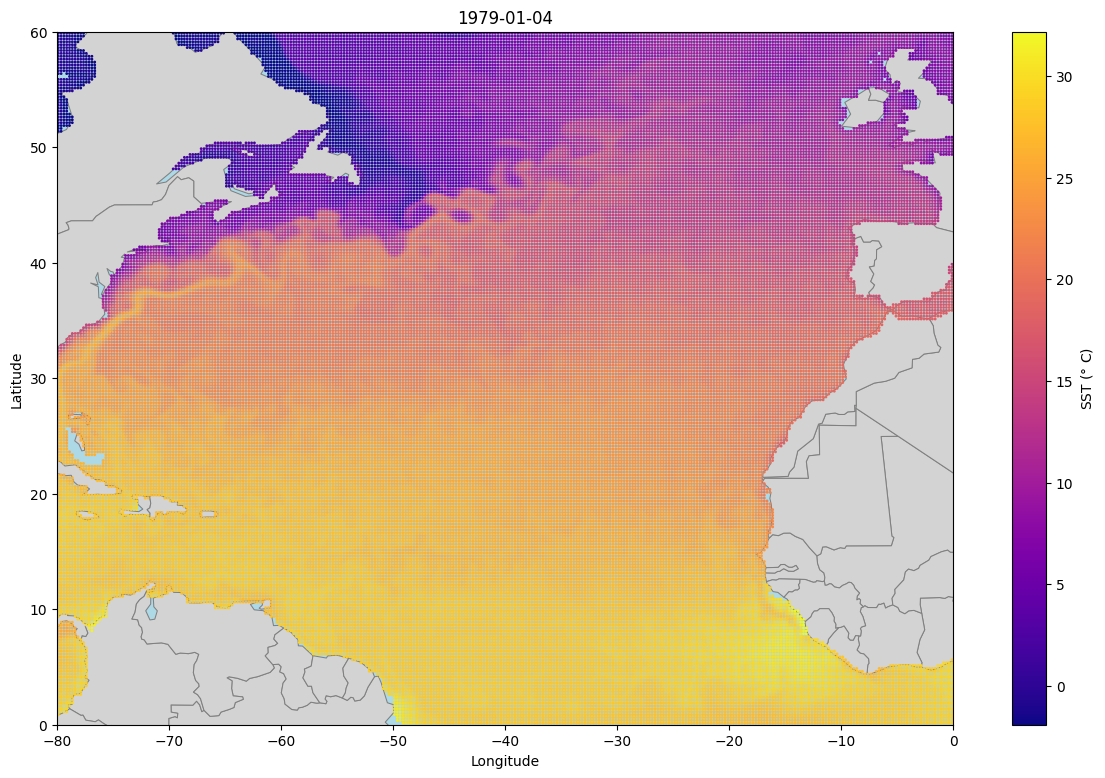

In [4]:
plot_sst_map(df, date, min(df.SST), max(df.SST), basin='NA')

# SHRED

In [5]:
num_sensors = 3
lags = 52

In [6]:
# Load and reformat data
data, dates, lats, longs = load_files()

print("Preprocessing data...")
train_data, val_data, test_data, train_dates, val_dates, test_dates = split_ordered_data(data, dates)

# Normalise data
sc = MinMaxScaler()
sc = sc.fit(train_data)  # Computes min and max from training data only (prevent data leakage)
train_transformed = sc.transform(train_data)  
val_transformed = sc.transform(val_data)
test_transformed = sc.transform(test_data)

# Build sequences
sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
print(f"Sensor location indexes will be: {sensor_locations}")

train_dataset = create_shred_sequences(train_transformed, sensor_locations, num_sensors=num_sensors, lags=lags)
val_dataset = create_shred_sequences(val_transformed, sensor_locations, num_sensors=num_sensors, lags=lags)
test_dataset = create_shred_sequences(test_transformed, sensor_locations, num_sensors=num_sensors, lags=lags)


Loading data: 100%|██████████| 1879/1879 [00:09<00:00, 193.90it/s]


Preprocessing data...
Sensor location indexes will be: [20184 34842 53041]


In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
shred = models.SHRED(num_sensors, len(lats), hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
validation_errors = models.fit(shred, train_dataset, val_dataset, batch_size=64, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

Training epoch 1
Error tensor(0.4676)
Training epoch 20
Error tensor(0.1855)
Training epoch 40
Error tensor(0.1725)
Training epoch 60
Error tensor(0.1644)
Training epoch 80
Error tensor(0.1686)
Training epoch 100
Error tensor(0.1645)
Training epoch 120
Error tensor(0.1697)
Training epoch 140
Error tensor(0.1692)
Training epoch 160
Error tensor(0.1826)


In [8]:
test_recons = sc.inverse_transform(shred(test_dataset.X).detach().cpu().numpy())
test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
print('Test Reconstruction Error: ')
print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

Test Reconstruction Error: 
0.033757437


In [13]:
np.save("recons", test_recons)

In [14]:
recon_df = pd.DataFrame({
    "Latitude": lats,
    "Longitude": longs,
    "SST": test_recons[0]
})

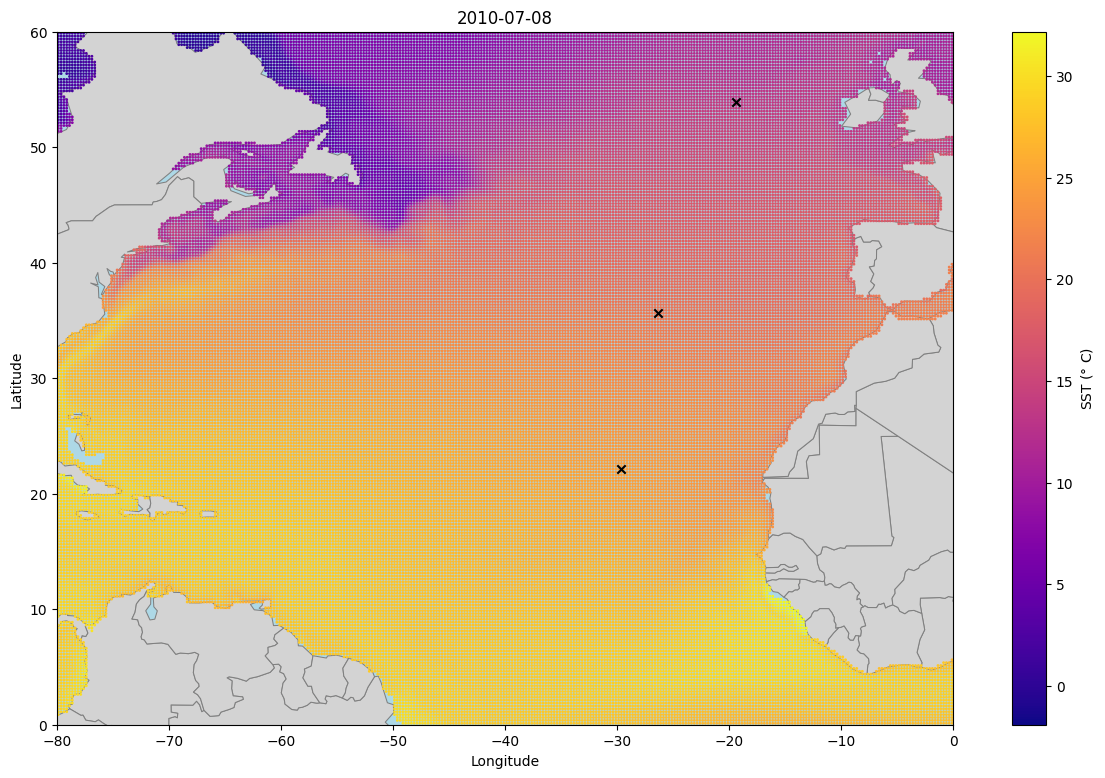

In [15]:
plot_sst_map(recon_df, str(test_dates[0].date()), min_sst=min(df.SST), max_sst=max(df.SST), basin='NA', sensor_coords=(longs[sensor_locations], lats[sensor_locations]))

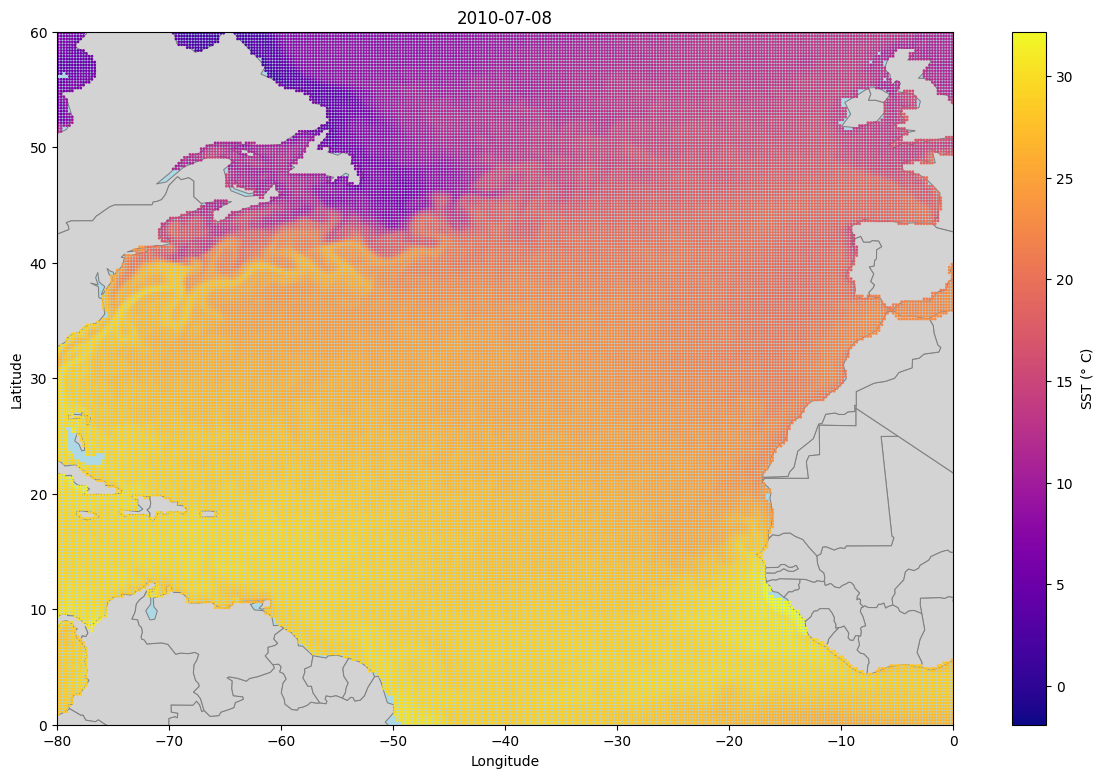

In [16]:
date = str(test_dates[0].date())
true_df = pd.read_csv(f"{NA_DATA_PATH}{date}.csv")
plot_sst_map(true_df, date, min(df.SST), max(df.SST), basin='NA')

In [17]:
date = str(test_dates[0].date())
date

'2010-07-08'

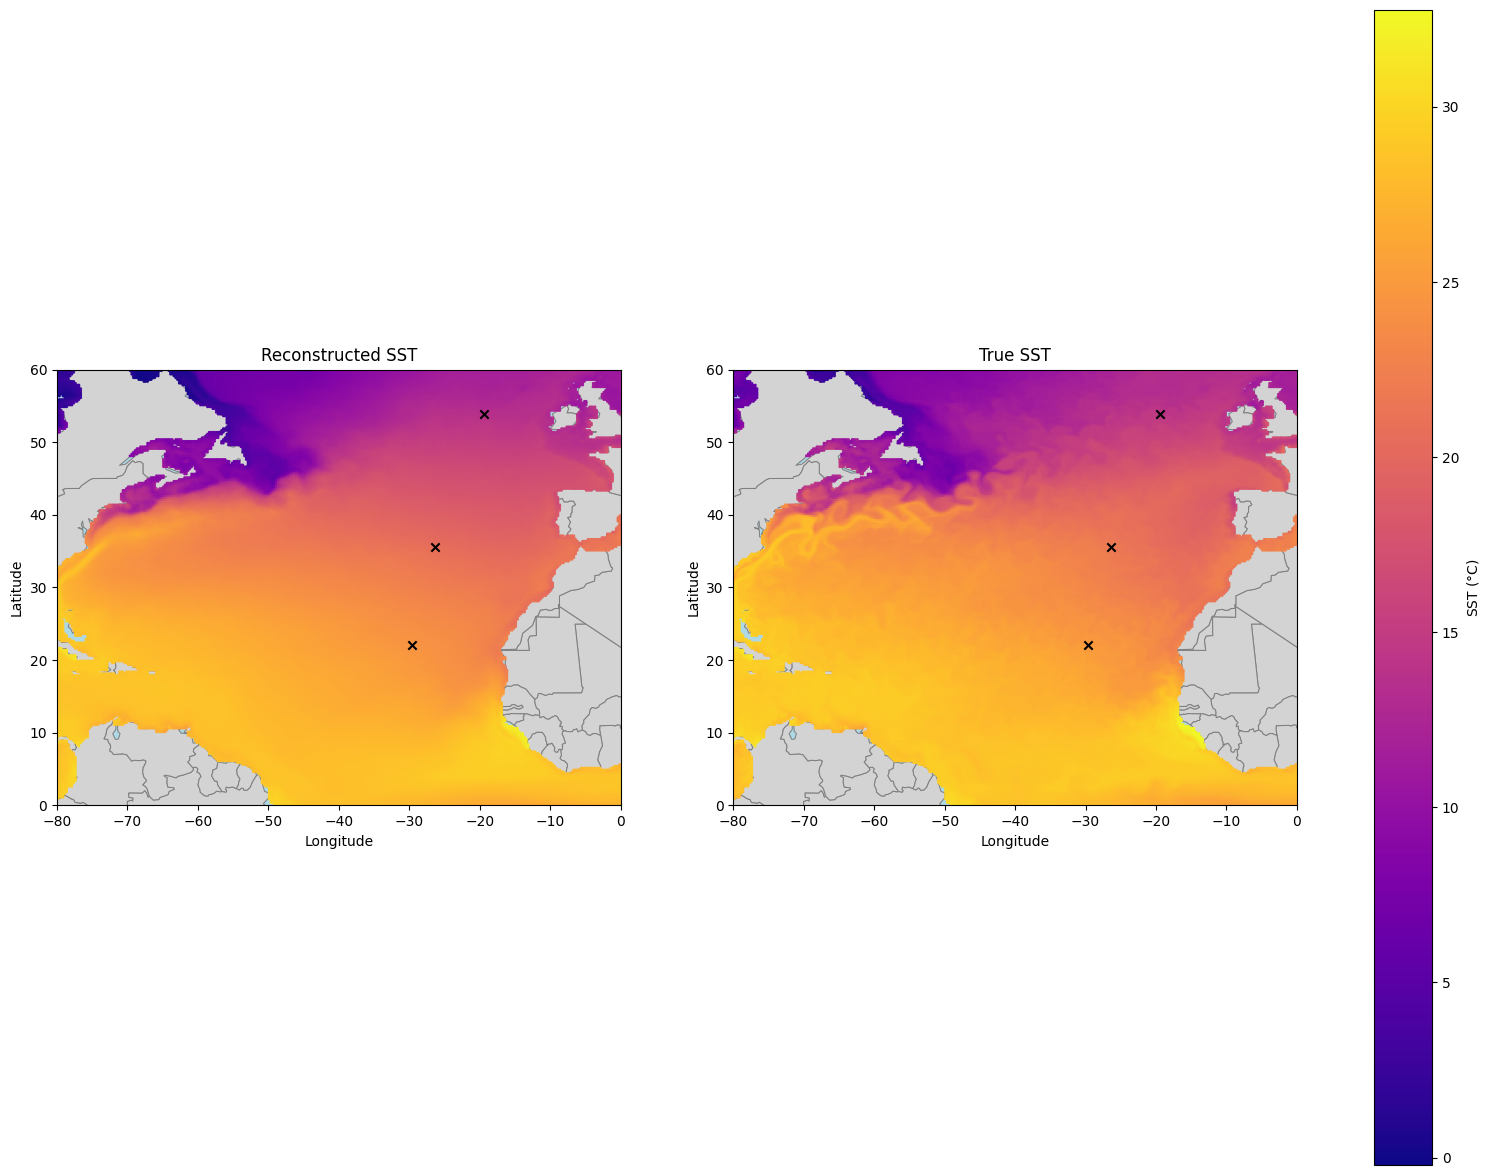

In [18]:
plot_compare_NA_sst_recon_truth(recon_df, true_df, sensor_coords=(longs[sensor_locations], lats[sensor_locations]))